In [41]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_excel('../mRNA_seq/mRNA_seq_AS_Control_LncRNA_identificados.xlsx')
#Eliminamos todas las variables que Norm ya que prefiero hacer nuestra propia normalizacion
df = df.loc[:, ~df.columns.str.contains('Raw')]
#trasponemos para que cada fila sea un paciente y cada columna sea una variable , incluimos el simbolo de hgnc como nombre de columnas  y eliminamos variables que son string
df = df.set_index('hgnc_symbol').drop(['description','gene_biotype','chromosome_name'],axis = 1).T

Como hay tantas variables, procedemos a descartar aquellas que sean redundantes

## Reducción de dimensionalidad

### Lecturas bajas

Consideramos variables con lectuas bajas aquellas que tengan una frecuencia mayor del 50% con lecturas de menor de un threshold:

In [4]:
for thres in [0.1,0.2,0.3,0.5,0.6,0.7,0.8,0.9]:
    estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < thres).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    })

    print(f'Lecturas menores de {thres} con una frecuencia de más del 50% hay', len(estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]),'variables')

Lecturas menores de 0.1 con una frecuencia de más del 50% hay 0 variables
Lecturas menores de 0.2 con una frecuencia de más del 50% hay 1 variables
Lecturas menores de 0.3 con una frecuencia de más del 50% hay 3 variables
Lecturas menores de 0.5 con una frecuencia de más del 50% hay 10 variables
Lecturas menores de 0.6 con una frecuencia de más del 50% hay 16 variables
Lecturas menores de 0.7 con una frecuencia de más del 50% hay 37 variables
Lecturas menores de 0.8 con una frecuencia de más del 50% hay 67 variables
Lecturas menores de 0.9 con una frecuencia de más del 50% hay 95 variables


Se elige 0.6

In [5]:
thres_elegido = 0.6

estadisticas = pd.DataFrame({
    'NoCeros': (df != 0).sum(),
    'CercanoCero': (df < thres_elegido).sum(),
    'Porcentaje de lencturas cercanas a cero' : (df < thres_elegido).sum()/35,
    'Media': df.mean(),
    'Desviación': df.std(),
    'Suma total': df.sum(),
    'Maximo' : df.max(),
    'Minimo' : df.min()
    }).sort_values('Porcentaje de lencturas cercanas a cero', ascending = False)
vars_est = estadisticas[estadisticas['Porcentaje de lencturas cercanas a cero'] > 0.5]
vars_est

,NoCeros,CercanoCero,Porcentaje de lencturas cercanas a cero,Media,Desviación,Suma total,Maximo,Minimo
hgnc_symbol,,,,,,,,
DNAAF4-CCPG1,35,27,0.800000,0.407633,0.687793,14.267146,2.909775,0.011532
LYPLAL1-AS1,35,23,0.714286,0.530408,0.425495,18.564288,1.953195,0.014390
LINC00865,35,25,0.714286,0.665514,0.785052,23.292979,3.530602,0.052633
LINC02388,35,21,0.685714,0.840344,1.071354,29.412056,3.792128,0.015304
LINC01697,35,22,0.685714,0.716995,0.951829,25.094813,3.921769,0.018421
LINC02506,35,21,0.657143,0.974187,1.751366,34.096542,7.400966,0.011532
LINC02160,35,21,0.657143,0.621431,0.468060,21.750100,1.830866,0.046138
LINC02427,35,17,0.600000,0.572845,0.359135,20.049577,1.340731,0.056041
LINC02804,35,21,0.600000,0.536994,0.479179,18.794805,1.704988,0.043169


In [6]:
vars_excluir = vars_est.reset_index()['hgnc_symbol'].to_list()
df1 = df.drop(columns=vars_excluir)

print(len(df.columns),'variables →',len(df1.columns),'variables')

695 variables → 679 variables


### Correlaciones

La correlación de Spearman no elimina ninguna variable ya que de acuerdo con ella, no hay ninguna correlación a un threshold > 0.95

In [7]:
df_list = []
threshold = 0.8
correlaciones_vars = df1.corr(method = 'spearman') #usar mejor Spearman, rank correlation
columns_to_drop = set()

# Iterar sobre la matriz de correlación y eliminar las columnas con correlación > 0.95
for i in range(len(correlaciones_vars.columns)):
    for j in range(i):
        if abs(correlaciones_vars.iloc[i, j]) > threshold:
            colname = correlaciones_vars.columns[i]
            columns_to_drop.add(colname)
nvarsAntes = len(df1.columns)        
df1 = df1.drop(columns=columns_to_drop)   
print(nvarsAntes,'variables →',len(df1.columns),'variables')

679 variables → 662 variables


### Tests

Se procede a hacer un test para cada variable para determinar si existen diferencias significativas entre el grupo de Tratamiento y Control. Esto nos permitirá saber si cada variable es estadíticamente diferente o no. Las que no son diferentes podemos procederlas a eliminarlas ya que el objetivo de este análisis es determinar las diferencias entre ambos grupos

In [8]:
from scipy.stats import shapiro, ttest_ind, mannwhitneyu, anderson_ksamp
from statsmodels.stats.multitest import multipletests

In [9]:
####Dividmos el data set en dos: Uno de tratamiento y otro de control

df1_ct = df1.copy().reset_index()
df1_ct['Grupo'] = np.where(df1_ct['index'].str.contains('A'), 'Tratamiento', 
              np.where(df1_ct['index'].str.contains('C'), 'Control', 'Otro'))
df1_ct = df1_ct.set_index('index')
df1_trnto = df1_ct[df1_ct['Grupo'] == 'Tratamiento'].drop('Grupo', axis = 1)
df1_ctrl = df1_ct[df1_ct['Grupo'] == 'Control'].drop('Grupo', axis = 1)
df1_ct = df1_ct.drop('Grupo', axis = 1)

In [10]:
variables = df1_ct.columns  
variablesIncluir = []
variablesExcluir = []
p_values = []
tests = []  # Para almacenar qué test se usó en cada variable

for var in variables:
    # Prueba de normalidad en ambos grupos
    p_value_trnto = shapiro(df1_trnto[var]).pvalue
    p_value_ctrl = shapiro(df1_ctrl[var]).pvalue
    # Primero comprobamos si los dos grupos siguen una distribución normal o no usando el test Shapiro-Wilk (para muestras pequeñas)
    
    if p_value_trnto > 0.05 and p_value_ctrl > 0.05:   # Si es normal, usamos t-student
        #Los dos p_values son normales → Usamos T_student
        stat, p_value = ttest_ind(df1_trnto[var], df1_ctrl[var], equal_var=False)  # Si el p-valor es menor que 0.05, diferencias significativas, Hay diferencias significativas entre los dos grupos
        test_name = 't-test'
    else:
        # Al menos un grupo no es normal → Usamos Mann-Whitney U
        stat, p_value = mannwhitneyu(df1_trnto[var], df1_ctrl[var], alternative='two-sided')
        test_name = 'Mann-Whitney'

    tests.append(test_name)
    p_values.append(p_value)  # Guardamos el p-valor obtenido

# Como se hacen muchas pruebas de manera reiterada, aplicamos la corrección FDR de Benjamini-Hochberg para evitar una acumulación de falsos positivos
reject, p_adjusted, _, _ = multipletests(p_values, method='fdr_bh')

# Clasificar variables según la corrección FDR
variablesIncluir = [var for var, r in zip(variables, reject) if r]
variablesExcluir = [var for var, r in zip(variables, reject) if not r]

# Guardar los resultados en un DataFrame
df_resultados = pd.DataFrame({
    'Variable': variables,
    'Test aplicado': tests,
    'p-valor original': p_values,
    'p-valor ajustado (FDR)': p_adjusted,
    'Rechazar H0 (FDR)': reject #Esto es si rechazamos la hipótesis nula de que no haya diferencias signitficativas, si es true, las hay, si es false, no las hay
})

In [11]:
print(len(variables),'→',len(variablesIncluir))

662 → 75


In [12]:
df1 = df1[variablesIncluir]

## Análisis

### Random Forest con todo el data set

In [106]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from tqdm import tqdm 
import pickle

In [127]:
scaler = StandardScaler()
df_scaled  = scaler.fit_transform(df1)
df_scaled = pd.DataFrame(df_scaled, columns=df1.columns)
df_scaled = df_scaled.set_index(df1.index)
df_scaled2 = df_scaled.copy()
df_scaled2 = df_scaled2.reset_index()
df_scaled2['Grupo'] = np.where(df_scaled2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled2['index'].str.contains('C'), 'Control', 'Otro'))
df_scaled2 = df_scaled2.set_index('index')
df_scaled2 = pd.get_dummies(df_scaled2, columns=['Grupo'], drop_first=True)
df_scaled2['Grupo_Tratamiento'] = df_scaled2['Grupo_Tratamiento'].astype(int)

#### Bootstrap

In [44]:
X = df_scaled2.drop(columns=[ "Grupo_Tratamiento"])  
y = df_scaled2["Grupo_Tratamiento"]
n_iteraciones = 5000
max_depth_options = list(range(3, 10))
min_samples_split_options = list(range(2, 30))
min_samples_leaf_options = list(range(1, 15))
n_estimators_options = list(range(1,200))
criterions = ['gini', 'entropy']
resultados = []

for i in tqdm(range(n_iteraciones), desc="Iterando modelos"):
    ##BOOTSTRAP
    sample_indices = np.random.choice(range(len(X)), size=len(X), replace=True)
    X_train = X.iloc[sample_indices]
    y_train = y.iloc[sample_indices]
    test_mask = ~np.isin(range(len(X)), sample_indices)
    X_test = X.iloc[test_mask]
    y_test = y.iloc[test_mask]

    # Hiperparámetros aleatorios
    n_estimators = random.choice(n_estimators_options)
    max_depth = random.choice(max_depth_options)
    min_samples_split = random.choice(min_samples_split_options)
    min_samples_leaf = random.choice(min_samples_leaf_options)
    criterion = random.choice(criterions)

    #Modelo
    rf  = RandomForestClassifier(
        n_estimators=n_estimators,
        criterion=criterion,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=random.choice(list(range(1,100000000)))
    )
    rf.fit(X_train, y_train)
    y_train_pred = rf.predict(X_train)
    y_test_pred = rf.predict(X_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    important_features = []
    for idx, f in enumerate(X.columns):
        importance = rf.feature_importances_[idx]
        if importance > 0:
            important_features.append((f, importance))
    if important_features:
        for feature, importance in important_features:
            resultados.append({
                'Iteration': i,
                'Feature': feature,
                'Importance': importance,
                'Train Accuracy': train_accuracy,
                'Test Accuracy': test_accuracy
            })

# Crear un DataFrame con los resultados
df_results = pd.DataFrame(resultados)

Iterando modelos:   0%|          | 0/5000 [00:00<?, ?it/s]

Iterando modelos: 100%|██████████| 5000/5000 [8:08:51<00:00,  5.87s/it]   


In [45]:
df_results = pd.DataFrame(resultados)
df_results.to_csv('../WorkingFiles/LncRNA_BootstrapRFDec.csv',index = False)

In [42]:
df_results = pd.read_csv('../WorkingFiles/LncRNA_BootstrapRFDec.csv')
temp_df = df_results.groupby('Feature').agg(
    Conteo=('Feature', 'count'),
    Promedio_Importancia=('Importance', 'mean'),
    Promedio_Train_accuracy=('Train Accuracy','mean'),
    Promedio_Test_accuracy=('Test Accuracy','mean')
).reset_index()

# Calcular porcentaje sobre el total
temp_df['Frecuencia'] = temp_df['Conteo'] / 5000

# Ordenar por porcentaje y promedio de importancia
mostImpFeaturesTree = temp_df.sort_values(by=['Frecuencia', 'Promedio_Importancia'], ascending=False)
mostImpFeaturesTree = mostImpFeaturesTree[['Feature', 'Conteo', 'Frecuencia','Promedio_Importancia', 'Promedio_Train_accuracy',
    'Promedio_Test_accuracy']]
# threshold_frec = 0.4
# mostImpFeaturesTree = mostImpFeaturesTree[mostImpFeaturesTree['Frecuencia'] >threshold_frec].reset_index(drop=True)
mostImpFeaturesTree = mostImpFeaturesTree.reset_index(drop=True)
mostImpFeaturesTree

,Feature,Conteo,Frecuencia,Promedio_Importancia,Promedio_Train_accuracy,Promedio_Test_accuracy
0,LINC02208,3014,0.6028,0.062468,0.953939,0.848354
1,ARRDC3-AS1,2920,0.5840,0.061404,0.953865,0.849624
2,DIO3OS,2740,0.5480,0.055748,0.956861,0.852778
3,LINC01569,2740,0.5480,0.052349,0.950865,0.847330
4,LINC00964,2599,0.5198,0.050887,0.958918,0.855400
...,...,...,...,...,...,...
70,LINC00346,1057,0.2114,0.016284,0.967969,0.857516
71,GAS6-AS1,1034,0.2068,0.020389,0.974744,0.864137
72,ST3GAL6-AS1,1021,0.2042,0.020650,0.960151,0.850465
73,DPP4-DT,883,0.1766,0.014488,0.969681,0.854245


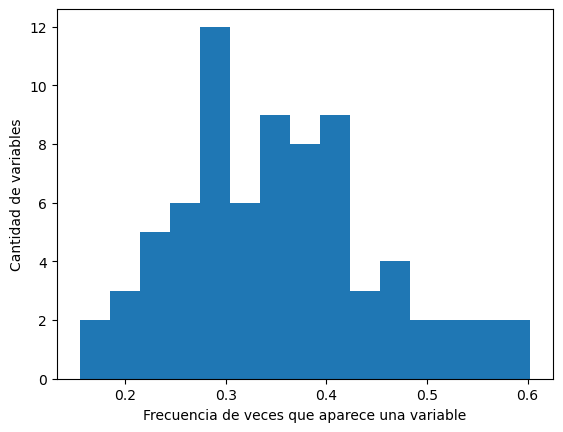

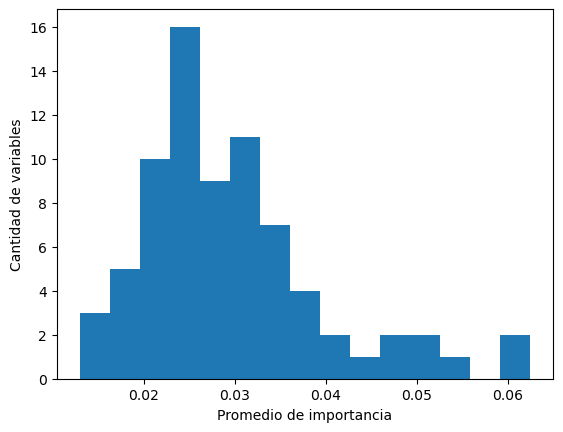

In [43]:
plt.hist(mostImpFeaturesTree['Frecuencia'],bins = 15)
plt.xlabel('Frecuencia de veces que aparece una variable')
plt.ylabel('Cantidad de variables')
plt.show()
plt.hist(mostImpFeaturesTree['Promedio_Importancia'],bins = 15)
plt.xlabel('Promedio de importancia')
plt.ylabel('Cantidad de variables')
plt.show()

In [49]:
from scipy.stats import zscore
frecs_data = mostImpFeaturesTree['Frecuencia']
z_scores = zscore(frecs_data)
outliers = frecs_data[z_scores > -5]
minFrec = outliers.min()
minFrec


0.3532

In [50]:
imp_data = mostImpFeaturesTree['Promedio_Importancia']
z_scores = zscore(imp_data)
outliers = imp_data[z_scores > -5]
minImp = outliers.min()
minImp

0.03024741024548234

In [51]:
mostImpFeaturesTree = mostImpFeaturesTree[(mostImpFeaturesTree['Frecuencia']>=minFrec) & (mostImpFeaturesTree['Promedio_Importancia'] >= minImp)]
mostImpFeaturesTree


,Feature,Conteo,Frecuencia,Promedio_Importancia,Promedio_Train_accuracy,Promedio_Test_accuracy
0,LINC02208,3014,0.6028,0.062468,0.953939,0.848354
1,ARRDC3-AS1,2920,0.5840,0.061404,0.953865,0.849624
2,DIO3OS,2740,0.5480,0.055748,0.956861,0.852778
3,LINC01569,2740,0.5480,0.052349,0.950865,0.847330
4,LINC00964,2599,0.5198,0.050887,0.958918,0.855400
5,OSER1-DT,2599,0.5198,0.046487,0.955137,0.847732
6,LINC01278,2552,0.5104,0.046445,0.958453,0.855856
7,CEROX1,2423,0.4846,0.042221,0.958528,0.849534
8,SNHG19,2333,0.4666,0.043221,0.963260,0.862802
9,LINC02254,2319,0.4638,0.042142,0.961782,0.854751


## Logistica

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
from sklearn.metrics import r2_score, accuracy_score
from tqdm import tqdm
from sklearn.utils import resample

In [26]:
df2 = df[mostImpFeaturesTree['Feature'].to_list()]
df2 = df2.reset_index()
df2['Grupo'] = np.where(df2['index'].str.contains('A'), 'Tratamiento', 
              np.where(df2['index'].str.contains('C'), 'Control', 'Otro'))
df2 = df2.set_index('index')
df2 = pd.get_dummies(df2, columns=['Grupo'], drop_first=True)
df2['Grupo_Tratamiento'] = df2['Grupo_Tratamiento'].astype(int)

In [28]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 10000
random_state = 42  
np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de variables seleccionadas
    X = X_total[vars_seleccionadas]
    y = y_total

    # Separar por clase
    X_0 = X[y == 0]
    X_1 = X[y == 1]
    y_0 = y[y == 0]
    y_1 = y[y == 1]

    # Balancear (tomar el mínimo de ambas clases para igualar)
    n_samples = min(len(X_0), len(X_1))

    # Bootstrap balanceado por clase
    X_0_boot, y_0_boot = resample(X_0, y_0, replace=True, n_samples=n_samples, random_state=None)
    X_1_boot, y_1_boot = resample(X_1, y_1, replace=True, n_samples=n_samples, random_state=None)

    # Concatenar clases balanceadas
    X_boot = pd.concat([X_0_boot, X_1_boot])
    y_boot = pd.concat([y_0_boot, y_1_boot])

    # Out-of-bag samples: eliminar los índices que fueron usados
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar modelo
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

# Convertir a DataFrame final
df_resultados = pd.DataFrame(resultados)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [01:23<00:00, 120.39it/s]


In [29]:
#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)').reset_index(drop=True)
df_resultados_bootstrpaLogit

,Variable,Conteo,Promedio_Coeficiente,Promedio_Train_accuracy,Promedio_Test_accuracy
0,ARRDC3-AS1,6197,0.706560,0.870311,0.735263
1,SNHG19,6153,-0.611466,0.868793,0.732754
2,LINC02208,6172,-0.544375,0.866877,0.730059
3,KRTAP5-AS1,6285,0.524854,0.868771,0.730291
4,LINC00964,6160,-0.514570,0.869414,0.733583
5,LINC01278,6198,0.511546,0.869239,0.731187
6,MIR34AHG,6326,0.510556,0.868472,0.731794
7,LINC01569,6279,0.494774,0.867466,0.728944
8,LINC01547,6204,0.448555,0.865519,0.728426
9,OSER1-DT,6214,-0.416482,0.866599,0.724369


# Borrador

In [ ]:
# Separar variables y target
X = df2.drop(columns='Grupo_Tratamiento')
X = X[coef_df['Variable'].to_list()]  # Seleccionar solo las variables del dataframe de coeficientes
y = df2['Grupo_Tratamiento']

# Estandarizar las variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Estándariza X sin la constante

X_scaled = pd.DataFrame(X_scaled, columns=X.columns,index = y.index)


# Ajustar el modelo de regresión logística
model = sm.Logit(y, X_scaled)
result = model.fit()

# Mostrar un resumen con p-valores, coeficientes y pseudo R^2
print(result.summary())

# Obtener el pseudo R^2 de McFadden
pseudo_r2 = 1 - (result.llf / result.llnull)
print(f"Pseudo R^2: {pseudo_r2}")

In [ ]:
# Inicializar lista para guardar los resultados
resultados = []

# Número de iteraciones del bootstrap
n_iter = 10000
random_state = 42  # puedes quitar esto si quieres total aleatoriedad

np.random.seed(random_state)

X_total = df2.drop(columns='Grupo_Tratamiento')
y_total = df2['Grupo_Tratamiento']
variables_totales = X_total.columns.tolist()

for i in tqdm(range(n_iter)):
    # Selección aleatoria de variables
    n_vars = np.random.randint(5, len(variables_totales) + 1)
    vars_seleccionadas = np.random.choice(variables_totales, size=n_vars, replace=False)

    # Subset de datos
    X = X_total[vars_seleccionadas]
    y = y_total

    # Hacer bootstrap del conjunto de entrenamiento (con reemplazo)
    X_boot, y_boot = resample(X, y, replace=True, n_samples=len(X), random_state=None)

    # Out-of-bag samples (muestras que no están en el bootstrap)
    mask = ~X.index.isin(X_boot.index)
    X_oob = X.loc[mask]
    y_oob = y.loc[mask]

    # Escalar
    scaler = StandardScaler()
    X_boot_scaled = scaler.fit_transform(X_boot)
    X_oob_scaled = scaler.transform(X_oob) if not X_oob.empty else None

    # Hiperparámetro aleatorio
    c_value = 10 ** np.random.uniform(-2, 2)

    # Entrenar
    modelo = LogisticRegression(penalty='l1', solver='liblinear', C=c_value, max_iter=1000)
    modelo.fit(X_boot_scaled, y_boot)

    # Evaluar (solo si hay muestras OOB)
    if X_oob_scaled is not None and len(y_oob) > 0:
        y_pred_oob = modelo.predict(X_oob_scaled)
        y_pred_boot = modelo.predict(X_boot_scaled)
        r2 = r2_score(y_oob, y_pred_oob)
        acc_oob = accuracy_score(y_oob, y_pred_oob)
        acc_boot = accuracy_score(y_boot, y_pred_boot)
    else:
        r2 = np.nan
        acc_oob = np.nan
        acc_boot = accuracy_score(y_boot, modelo.predict(X_boot_scaled))

    # Guardar resultados
    for var, coef in zip(vars_seleccionadas, modelo.coef_[0]):
        resultados.append({
            'Iteración': i,
            'Variable': var,
            'Coeficiente': coef,
            'C': c_value,
            'R2': r2,
            'Accuracy_Test': acc_oob,
            'Accuracy_Train': acc_boot
        })

df_resultados = pd.DataFrame(resultados)

#df_resultados = df_resultados[df_resultados['Coeficiente'] != 0]
df_resultados_bootstrpaLogit = df_resultados.groupby('Variable').agg(
    Conteo=('Variable', 'count'),
    Promedio_Coeficiente=('Coeficiente', 'mean'),
    Promedio_Train_accuracy=('Accuracy_Train','mean'),
    Promedio_Test_accuracy=('Accuracy_Test','mean')
).reset_index()



# Ordenar por porcentaje y promedio de importancia

df_resultados_bootstrpaLogit['Importancia (abs)'] = np.abs(df_resultados_bootstrpaLogit['Promedio_Coeficiente'])
df_resultados_bootstrpaLogit = df_resultados_bootstrpaLogit.sort_values(by=['Importancia (abs)'], ascending=False).drop(columns='Importancia (abs)')
df_resultados_bootstrpaLogit

In [ ]:
#####CLUSTERING PARA SABER SI INDIVIDUOS DE CONTROL O TRATAMIENTO SE INCLUYEN EN UN MISMO CLUSTER

# Método del Codo
df_scaled1 = df_scaled.copy()
inertia = []
silhouette_scores = []
range_n_clusters = range(2, 11)  # Evaluamos entre 2 y 10 clusters

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(df_scaled1)
    
    # Guardamos la inercia para la técnica del codo
    inertia.append(kmeans.inertia_)
    
    # Calculamos el score de silueta para el método de silueta
    score = silhouette_score(df_scaled1, kmeans.labels_)
    silhouette_scores.append(score)

# Gráfico del Método del Codo
plt.figure(figsize=(14, 6))

# Subgráfico para la técnica del codo
plt.subplot(1, 2, 1)
plt.plot(range_n_clusters, inertia, marker='o', linestyle='--', color='b')
plt.title('Método del Codo')
plt.xlabel('Número de clusters')
plt.ylabel('Inercia')
plt.grid(True)

# Subgráfico para el Método de la Silueta
plt.subplot(1, 2, 2)
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='--', color='r')
plt.title('Método de la Silueta')
plt.xlabel('Número de clusters')
plt.ylabel('Puntaje de Silueta')
plt.grid(True)

plt.tight_layout()
plt.show()

ncluster = 2
kmeans = KMeans(n_clusters=ncluster, random_state=42) #2 clusters, uno de control y otro de tratamiento
kmeans.fit(df_scaled1)
# Asignar cada variable a un cluster
clusters = kmeans.labels_
df_scaled1['cluster'] = clusters

for cluster in range(ncluster):
    df_scaled1Clust = df_scaled1[df_scaled1['cluster'] == cluster].reset_index()
    df_scaled1Clust['Grupo'] = np.where(df_scaled1Clust['index'].str.contains('A'), 'Tratamiento', 
              np.where(df_scaled1Clust['index'].str.contains('C'), 'Control', 'Otro'))
    conteo = df_scaled1Clust['Grupo'].value_counts()
    proporcion = df_scaled1Clust['Grupo'].value_counts(normalize=True) * 100
    print('CLUSTER',cluster)
    for categoria, (cantidad, prop) in zip(conteo.index, zip(conteo, proporcion)):
            print(f"{categoria}: {cantidad} ({prop:.2f}%)")

In [ ]:
############################################ OLS ############################
import statsmodels.api as sm

X = df_scaled2.drop(columns=["Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 5 variables aleatorias y hacer la regresión
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 5 variables
    selected_features = random.sample(list(X.columns), 5)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    # Ajustar el modelo de regresión lineal
    model = sm.OLS(y, X_selected_with_intercept)
    result = model.fit()
    
    for feature in selected_features:
        coefficients_dict[feature].append((float(result.params[feature])))
        p_values_dict[feature].append((float(result.pvalues[feature])))
        


mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

results_df = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

results_df = results_df[results_df['P-Valor Promedio']<0.05]
mostImpFeaturesRegression = results_df.sort_values('Coeficiente Promedio', ascending = False)
mostImpFeaturesRegression

In [ ]:
########################################### LOGÍSTICA ###################################33
import warnings
warnings.filterwarnings("ignore")

X = df_scaled2.drop(columns=["cluster", "Grupo_Tratamiento"]) 
y = df_scaled2["Grupo_Tratamiento"]  

# Lista para almacenar los coeficientes y p-valores
coefficients_dict = {col: [] for col in X.columns}  
p_values_dict = {col: [] for col in X.columns}

# Número de iteraciones
n_iterations = 5000  # Puedes modificar el número de iteraciones

# Realizamos el loop para seleccionar 3 variables aleatorias y hacer la regresión logística
for _ in range(n_iterations):
    # Seleccionar aleatoriamente 3 variables
    selected_features = random.sample(list(X.columns), 1)
    X_selected = X[selected_features]
    
    # Añadir la constante (intercepto)
    X_selected_with_intercept = sm.add_constant(X_selected)
    
    try:
        model = sm.Logit(y, X_selected_with_intercept)
        result = model.fit(disp=0)  # Evita que se muestre el resultado durante el ajuste
        
        for feature in selected_features:
            coefficients_dict[feature].append(float(result.params[feature]))
            p_values_dict[feature].append(float(result.pvalues[feature]))
    except:
        # Si ocurre un error (como singularidad), simplemente continuar con la siguiente iteración
        continue
# Calcular las medias de los coeficientes y p-valores
mean_coefficients = {k: np.sum(v)/len(v) for k, v in coefficients_dict.items()}
mean_p_values = {k: np.sum(v)/len(v) for k, v in p_values_dict.items()}

# Crear DataFrame con los resultados
results_df_log = pd.DataFrame({
    'Variable': list(mean_coefficients.keys()),
    'Coeficiente Promedio': list(mean_coefficients.values()),
    'P-Valor Promedio': list(mean_p_values.values())
})

# Filtrar para obtener solo aquellas variables con p-valor menor que 0.05
#results_df = results_df[results_df['P-Valor Promedio'] < 0.05]

results_df_log_MasSignificativos = results_df_log[results_df_log['P-Valor Promedio'] < 0.05].sort_values('Coeficiente Promedio',ascending = False)
#results_df_log_MasSignificativos['CoeficienteInterpretacion'] = np.exp(results_df_log_MasSignificativos['Coeficiente Promedio'])
results_df_log_MasSignificativos = results_df_log_MasSignificativos
results_df_log_MasSignificativos

In [ ]:
########### COMPARACIÓN DE RESULTADOS


treelist = mostImpFeaturesTree['Feature'].to_list()
reglist = mostImpFeaturesRegression['Variable'].to_list()
loglists = results_df_log_MasSignificativos['Variable'].to_list()

all_items = set(treelist + reglist + loglists)
df_comparacion = pd.DataFrame({'variable': list(all_items)})
df_comparacion['Arbol'] = df_comparacion['variable'].isin(treelist).astype(int)
df_comparacion['OLS'] = df_comparacion['variable'].isin(reglist).astype(int)
df_comparacion['Logistic'] = df_comparacion['variable'].isin(loglists).astype(int)

df_comparacion['frecuencia_total'] = (
    df_comparacion['Arbol'] +
    df_comparacion['OLS'] +
    df_comparacion['Logistic']
)
df_comparacion = df_comparacion.sort_values(by='frecuencia_total', ascending=False)
df_comparacion[df_comparacion['frecuencia_total'] >= 2]